# TAO ADCP Spectral Validation: TPOSE24 vs Observed Velocity

Compares the frequency content of TPOSE24 model velocity against TAO ADCP observations at 0°N, 140°W.  
Same profiles used in `notebook_1_tao_validation.ipynb`.

**1-D spectra:** PSD computed at each depth first, then averaged in depth.  
This is the correct order: averaging velocities in depth first would give only the spectrum of the depth-coherent (barotropic-like) signal, discarding internal-wave and shear variability. Averaging the per-depth PSDs preserves the full variance at every level.

**2-D spectra:** PSD as a function of both frequency and depth — shows where in the water column spectral energy lives.

In [1]:
# ──── run parameters ────
SUBFOLDER = '3month'
RUN_DIR   = '/data/SO3/edavenport/tpose24/oct2012_3month_transp_cons'

In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cmocean.cm as cmo
import pandas as pd
import os
import warnings
from scipy.signal import welch

warnings.filterwarnings('ignore')
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})

os.makedirs(f'TAO_comparison/{SUBFOLDER}', exist_ok=True)
DATA_PATH = f'{RUN_DIR}/PROF_eq/TAO_WO_2012_ADCP_v2_model.nc'

## 1. Load data

In [3]:
ds = xr.open_dataset(DATA_PATH)

lons       = ds['prof_lon'].values
depths     = ds['prof_depth'].values          # (62,) metres, 5-m spacing
dates_raw  = ds['prof_YYYYMMDD'].values
times_raw  = ds['prof_HHMMSS'].values

U      = ds['prof_U'].values.astype(float)
V      = ds['prof_V'].values.astype(float)
Uestim = ds['prof_Uestim'].values.astype(float)
Vestim = ds['prof_Vestim'].values.astype(float)

def parse_datetime(yyyymmdd, hhmmss):
    d, t = int(yyyymmdd), int(hhmmss)
    yr, mo, dy = d // 10000, (d % 10000) // 100, d % 100
    hh, mm, ss = t // 10000, (t % 10000) // 100, t % 100
    return pd.Timestamp(yr, mo, dy, hh, mm, ss)

timestamps = np.array([parse_datetime(d, t) for d, t in zip(dates_raw, times_raw)])

TARGET_LON = -140.
lon_mask   = lons == TARGET_LON
estim_mask = ~np.isnan(Uestim[lon_mask]).any(axis=1)

t_all  = timestamps[lon_mask][estim_mask]
U_all  = U[lon_mask][estim_mask]       # (n_prof, n_z)
V_all  = V[lon_mask][estim_mask]
Ue_all = Uestim[lon_mask][estim_mask]
Ve_all = Vestim[lon_mask][estim_mask]

n_prof, n_z = U_all.shape
dt_h = 1.0   # hourly sampling confirmed

print(f'Profiles: {n_prof}  |  Depths: {n_z} ({depths[0]:.0f}–{depths[-1]:.0f} m)')
print(f'Period: {t_all[0].date()} – {t_all[-1].date()}  |  dt = {dt_h} h')

Profiles: 2180  |  Depths: 62 (10–315 m)
Period: 2012-10-01 – 2012-12-30  |  dt = 1.0 h


## 2. Welch PSD at each depth

`nperseg=1024` gives ~42-day segments (max resolvable period 1024 h), at the cost of only ~3 Welch segments over the 91-day record — estimates at the low-frequency end will be noisier than the tidal band.

In [4]:
NPERSEG = 1024  # ~42-day segments; max period 1024 h; ~3 Welch segments
FS      = 1.0 / dt_h

f = np.fft.rfftfreq(NPERSEG, d=dt_h)

def psd_all_depths(arr2d):
    """Return psd (n_freq, n_z); NaN where depth column has missing data."""
    psd = np.full((len(f), arr2d.shape[1]), np.nan)
    for iz in range(arr2d.shape[1]):
        col = arr2d[:, iz]
        if not np.isfinite(col).all():
            continue
        _, p = welch(col - col.mean(), fs=FS, nperseg=NPERSEG, detrend='constant')
        psd[:, iz] = p
    return psd

psd_U_obs = psd_all_depths(U_all)
psd_V_obs = psd_all_depths(V_all)
psd_U_mod = psd_all_depths(Ue_all)
psd_V_mod = psd_all_depths(Ve_all)

# Mask model depths where obs has no data
psd_U_mod = np.where(np.isnan(psd_U_obs), np.nan, psd_U_mod)
psd_V_mod = np.where(np.isnan(psd_V_obs), np.nan, psd_V_mod)

T_h = 1.0 / f[1:]

# Depth-averaged 1-D PSD (spectrum first, then average)
psd1d_U_obs = np.nanmean(psd_U_obs[1:], axis=1)
psd1d_V_obs = np.nanmean(psd_V_obs[1:], axis=1)
psd1d_U_mod = np.nanmean(psd_U_mod[1:], axis=1)
psd1d_V_mod = np.nanmean(psd_V_mod[1:], axis=1)

print(f'Frequency resolution: {f[1]:.5f} cph  ({1/f[1]:.0f} h period)')
print(f'Nyquist period: {1/f[-1]*2:.1f} h')

Frequency resolution: 0.00098 cph  (1024 h period)
Nyquist period: 4.0 h


## 3. 1-D spectra: depth-averaged PSD

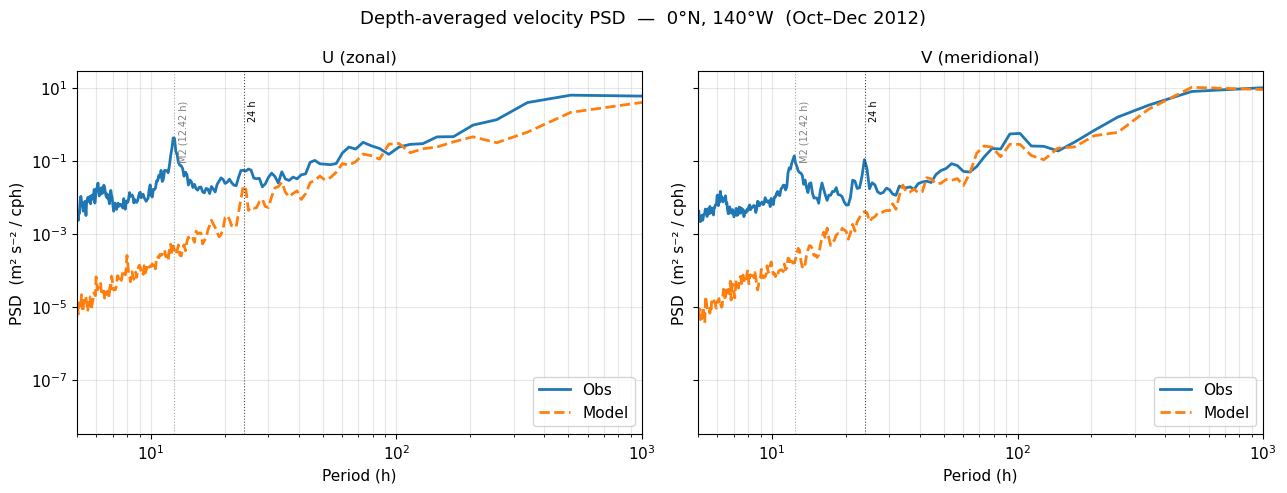

Saved fig_spectra_1d.png


In [5]:
# (period, label_y_axes_fraction, line_color)
# K1 is labeled "24 h" — record is too short to separate diurnal constituents
tidal_marks = {'24 h':         (23.93, 0.92, 'black'),
               'M2 (12.42 h)': (12.42, 0.92, 'gray')}

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
fig.suptitle('Depth-averaged velocity PSD  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

for ax, obs, mod, comp in zip(axes,
                               [psd1d_U_obs, psd1d_V_obs],
                               [psd1d_U_mod, psd1d_V_mod],
                               ['U (zonal)', 'V (meridional)']):
    ax.loglog(T_h, obs, color='C0', lw=2, label='Obs')
    ax.loglog(T_h, mod, color='C1', lw=2, ls='--', label='Model')

    trans = ax.get_xaxis_transform()
    for label, (period, y_ax, color) in tidal_marks.items():
        ax.axvline(period, color=color, lw=0.8, ls=':', alpha=0.7)
        ax.text(period * 1.04, y_ax, label, transform=trans,
                fontsize=7, color=color, rotation=90, ha='left', va='top')

    ax.set_xlabel('Period (h)')
    ax.set_ylabel('PSD  (m² s⁻² / cph)')
    ax.set_title(comp)
    ax.set_xlim([5, 1000])
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

fig.tight_layout()
plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_1d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_1d.png')

## 4. 1-D spectra at selected depths

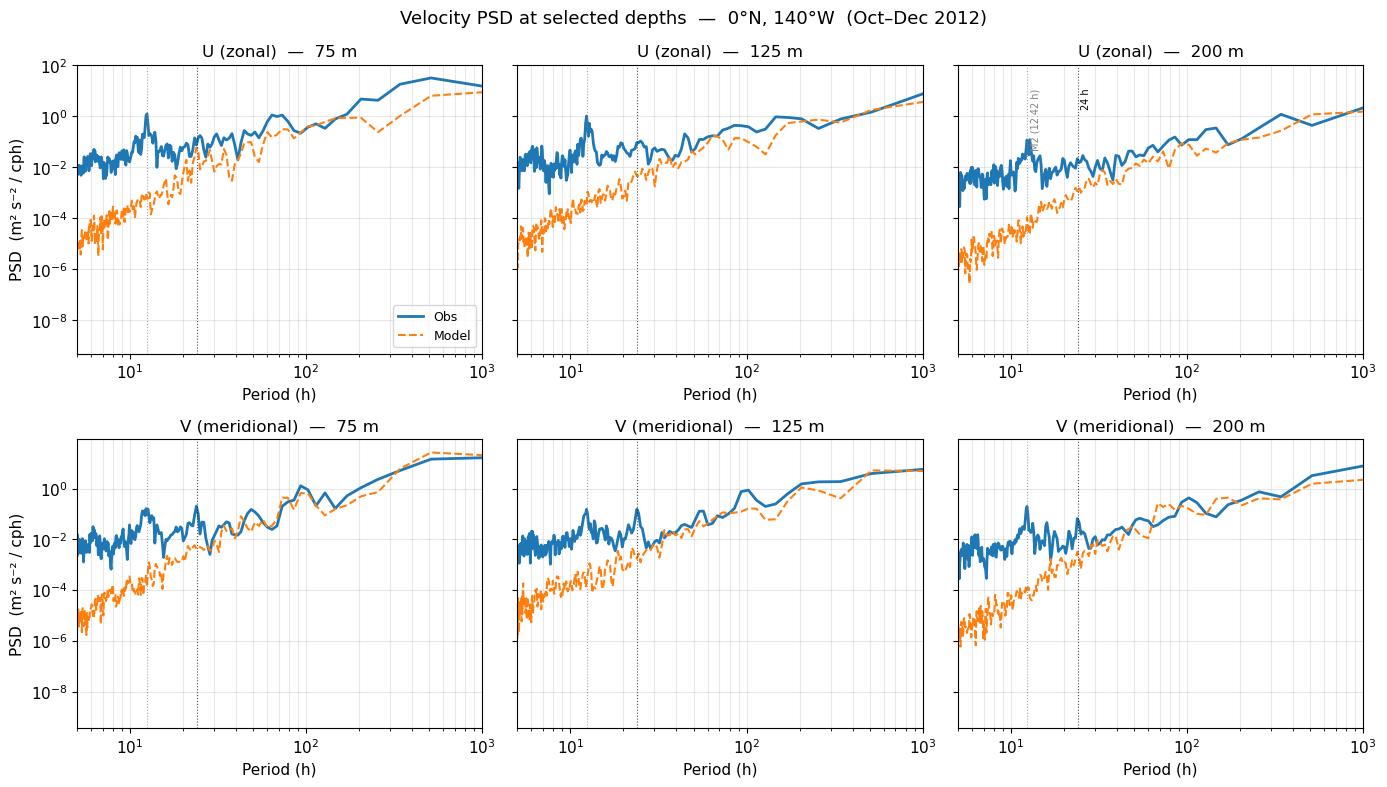

Saved fig_spectra_1d_depths.png


In [6]:
TARGET_DEPTHS = [75, 125, 200]
depth_idxs = [np.argmin(np.abs(depths - d)) for d in TARGET_DEPTHS]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey='row')
fig.suptitle('Velocity PSD at selected depths  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

for row, (psd_obs_2d, psd_mod_2d, comp) in enumerate([
        (psd_U_obs, psd_U_mod, 'U (zonal)'),
        (psd_V_obs, psd_V_mod, 'V (meridional)')]):
    for col, (iz, td) in enumerate(zip(depth_idxs, TARGET_DEPTHS)):
        ax = axes[row, col]
        ax.loglog(T_h, psd_obs_2d[1:, iz], color='C0', lw=2, label='Obs')
        ax.loglog(T_h, psd_mod_2d[1:, iz], color='C1', lw=1.5, ls='--', label='Model')

        trans = ax.get_xaxis_transform()
        for lbl, (period, y_ax, color) in tidal_marks.items():
            ax.axvline(period, color=color, lw=0.8, ls=':', alpha=0.7)
            if row == 0 and col == len(TARGET_DEPTHS) - 1:
                ax.text(period * 1.04, y_ax, lbl, transform=trans,
                        fontsize=7, color=color, rotation=90, ha='left', va='top')

        ax.set_xlim([5, 1000])
        ax.set_title(f'{comp}  —  {depths[iz]:.0f} m')
        ax.set_xlabel('Period (h)')
        ax.grid(True, which='both', alpha=0.3)
        if col == 0:
            ax.set_ylabel('PSD  (m² s⁻² / cph)')
        if row == 0 and col == 0:
            ax.legend(fontsize=9)

fig.tight_layout()
plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_1d_depths.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_1d_depths.png')

## 5. 2-D spectra: PSD as a function of frequency and depth

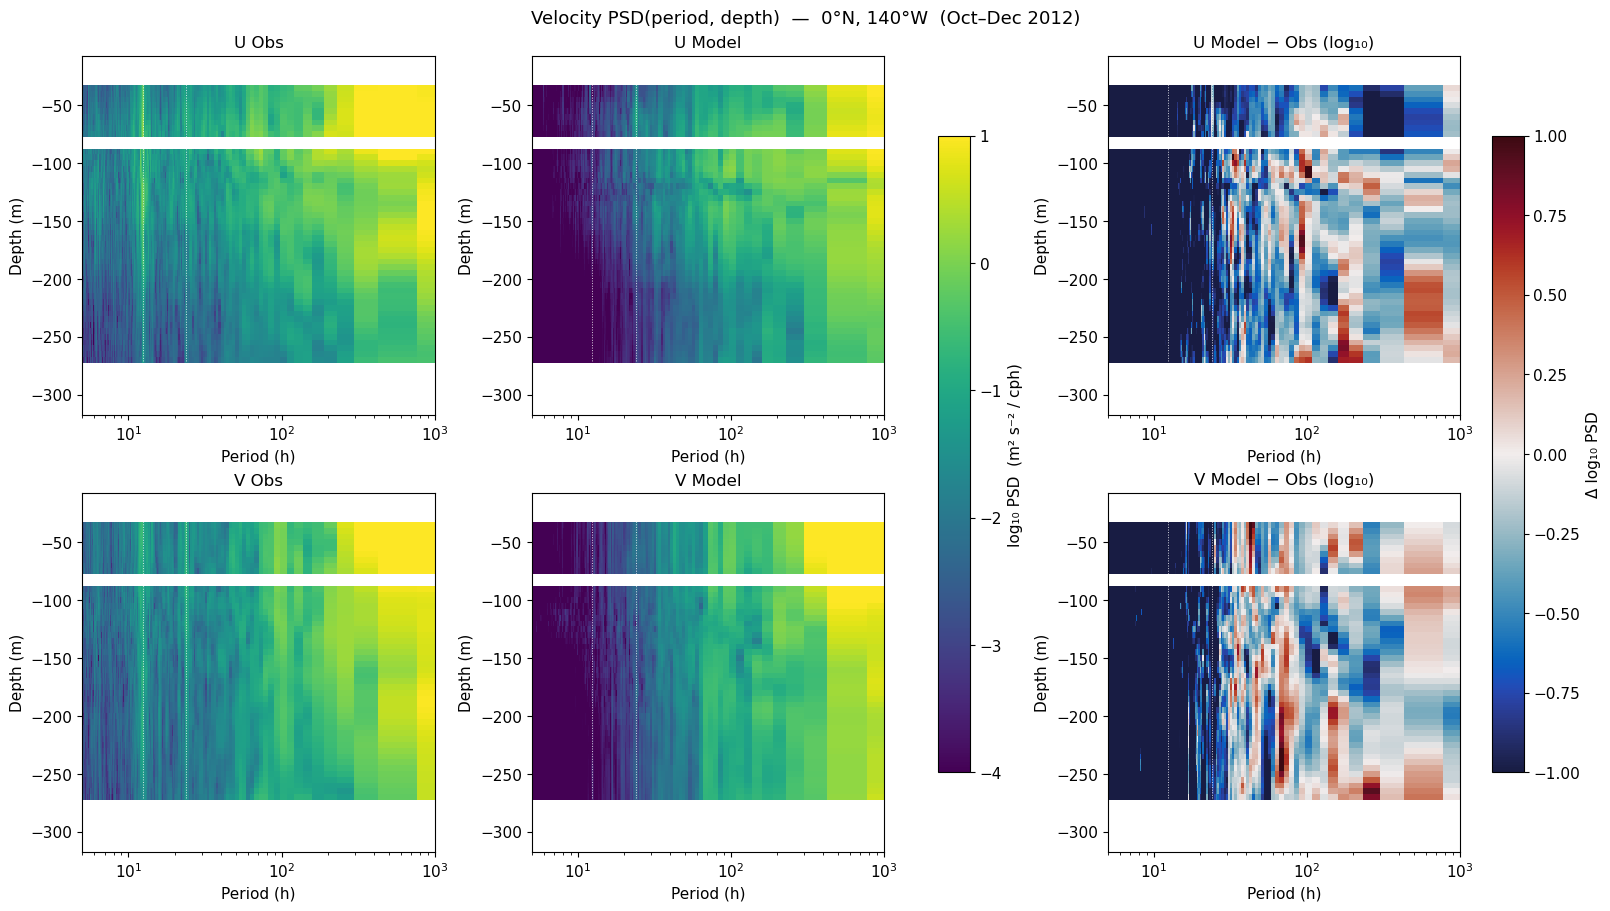

Saved fig_spectra_2d.png


In [7]:
Z = -depths

def log_psd(psd):
    p = psd[1:]
    with np.errstate(divide='ignore'):
        return np.log10(np.where(p > 0, p, np.nan))

logP_U_obs = log_psd(psd_U_obs)
logP_V_obs = log_psd(psd_V_obs)
logP_U_mod = log_psd(psd_U_mod)
logP_V_mod = log_psd(psd_V_mod)

vmin, vmax = -4, 1

fig, axes = plt.subplots(2, 3, figsize=(16, 9), constrained_layout=True)
fig.suptitle('Velocity PSD(period, depth)  —  0°N, 140°W  (Oct–Dec 2012)', fontsize=13)

def plot_row(axes_row, logP_obs, logP_mod, comp):
    kw = dict(cmap='viridis', vmin=vmin, vmax=vmax, shading='auto', rasterized=True)
    diff_kw = dict(cmap=cmo.balance, vmin=-1, vmax=1, shading='auto', rasterized=True)

    im_obs  = axes_row[0].pcolormesh(T_h, Z, logP_obs.T, **kw)
    im_mod  = axes_row[1].pcolormesh(T_h, Z, logP_mod.T, **kw)
    im_diff = axes_row[2].pcolormesh(T_h, Z, (logP_mod - logP_obs).T, **diff_kw)

    for ax, title in zip(axes_row, [f'{comp} Obs', f'{comp} Model', f'{comp} Model − Obs (log₁₀)']):
        ax.set_title(title)
        ax.set_ylabel('Depth (m)')
        ax.set_xlabel('Period (h)')
        ax.set_xscale('log')
        ax.set_xlim([5, 1000])
        for period, _, _ in tidal_marks.values():
            ax.axvline(period, color='white', lw=0.7, ls=':', alpha=0.8)

    return im_obs, im_diff

im_u, im_ud = plot_row(axes[0], logP_U_obs, logP_U_mod, 'U')
im_v, im_vd = plot_row(axes[1], logP_V_obs, logP_V_mod, 'V')

fig.colorbar(im_u,  ax=axes[:, :2], shrink=0.8, label='log₁₀ PSD  (m² s⁻² / cph)')
fig.colorbar(im_ud, ax=axes[:, 2],  shrink=0.8, label='Δ log₁₀ PSD')

plt.savefig(f'TAO_comparison/{SUBFOLDER}/fig_spectra_2d.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved fig_spectra_2d.png')